##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

**Load and merge datasets**

In [2]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.

df_ships1 = pd.read_csv("ships_inventory_iter1_clean.csv")
df_ships1.head(5)

,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
0,0,7316160254,4950.0,7505.0,Galactic Motors,Mon Cala Ocean Worlds
1,1,7316115206,18999.0,7518.0,Galactic Motors,Thraxos Blockade
2,2,7315865657,4000.0,7486.0,Republic Aerospace,Indoumodo Sector
3,3,7314772431,6495.0,7511.0,Nebula Industries,Pantora Moon
4,4,7311539325,3995.0,7499.0,Corellian Engineering,Malastare Narrows


In [3]:
df_ships2 = pd.read_csv("ship_inspections_iter2.csv")
df_ships2.head(5)

,Ship_ID,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316814884,Operational,80.0,Ion Drive,Hauler
1,7316814758,Operational,80.0,Hyperdrive,Hauler
2,7316814989,Pristine,80.0,Hyperdrive,Hauler
3,7316743432,Pristine,80.0,Plasma Thruster,Hauler
4,7316356412,Operational,60.0,Ion Drive,Freighter


In [4]:
#left join to keep previous data intact without introducing more unknown data
df_merged = df_ships1.merge(df_ships2, left_on='Ship_ID', right_on='Ship_ID', how='left')
df_merged.head()


,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,0,7316160254,4950.0,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,1,7316115206,18999.0,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,2,7315865657,4000.0,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,3,7314772431,6495.0,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,4,7311539325,3995.0,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**
*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

Nebula Brokerage has recieved new date about their inventory of ships, this data is however recorded in a new seperate data file. The data has large gaps in propulsion types due to broken sensors and there is a rumor that there are illegal overclocked reactors. going on gut feeling during the sale could lead to the company selling illegal ships or the wrong propulsion type to a custommer.

**Business objective(s)**
*Justify why a standardized, rule-based expert system is needed.*

we need to build a model that fills in the gaps in the data using other data to make the best posible prediction of what the data should look like.
our model also needs to easily indicate if a ship has illegal overclocked reactors.

**Data mining goal(s)**
*Explain what type of modeling task this is and why.*

TODO

**Success criteria**
*Determine success criteria for this iteration*

TODO

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In [5]:
# CODE CELL: Show basic statistics and information
df_merged.info()
df_merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368314 entries, 0 to 368313
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         368314 non-null  int64  
 1   Ship_ID            368314 non-null  int64  
 2   Galactic_Credits   368314 non-null  float64
 3   Model_Cycle        368314 non-null  float64
 4   Ship_Manufacturer  368314 non-null  object 
 5   Sector             368314 non-null  object 
 6   Hull_Integrity     368314 non-null  object 
 7   Reactor_Power      338876 non-null  float64
 8   Propulsion_Type    311704 non-null  object 
 9   Ship_Class         368314 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 28.1+ MB


,Unnamed: 0,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,368314.000000,3.683140e+05,368314.000000,368314.000000,338876.000000
mean,184360.748147,7.311484e+09,19246.013711,7511.298854,71.592559
std,106475.762442,4.381194e+06,14124.469519,8.991369,44.644147
min,0.000000,7.301583e+09,501.000000,7400.000000,30.000000
25%,92143.250000,7.308103e+09,7950.000000,7508.000000,40.000000
50%,184337.500000,7.312604e+09,15990.000000,7513.000000,60.000000
75%,276576.750000,7.315244e+09,27990.000000,7517.000000,80.000000
max,368813.000000,7.317101e+09,68788.000000,7522.000000,360.000000


there are 4 new rows of data added with the second data set.

Hull_Integrity, a string that represents the condition of the hull of the ship (prestine, operational and critical).
important for quicly understanding the condition the ship is in.

Reactor_Power, a number representing how powerfull the ships reactor is.
a large diviation in this number could indicate problems such as overclocking.

Propulsion type, what propulsion the shup uses.
general data about the ships with large gaps due to a sensor mallfunction.

Ship class, what the ship is used for.
usefull to know for buyers.


**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

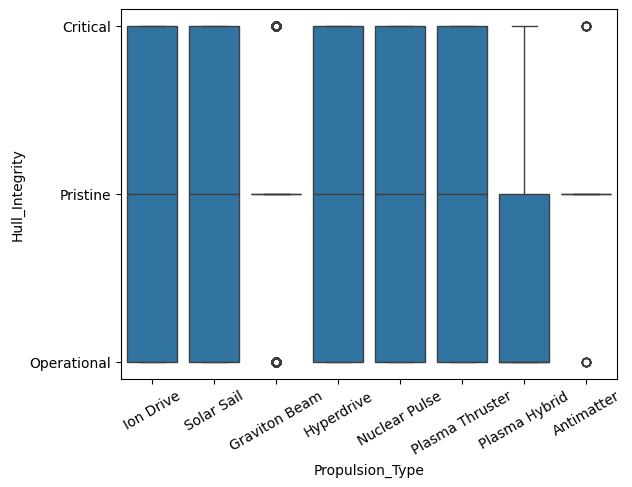

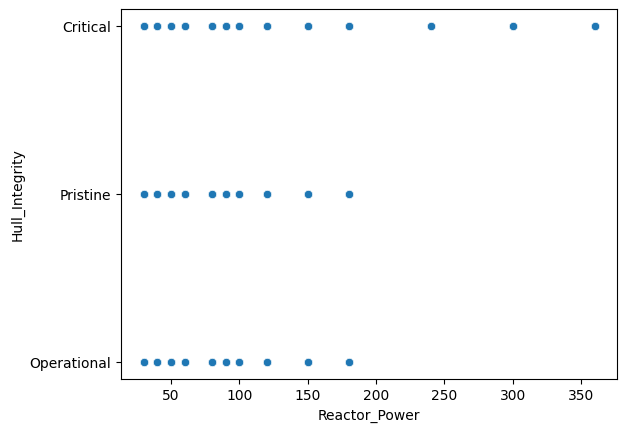

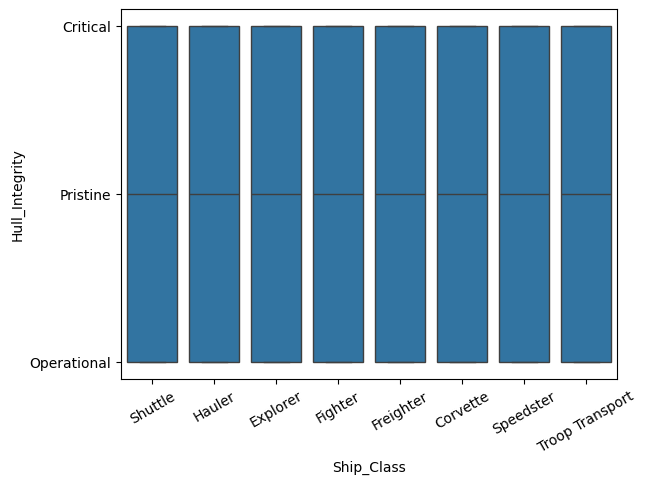

In [12]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
sns.boxplot(x='Propulsion_Type', y='Hull_Integrity', data=df_merged)
plt.xticks(rotation=30)
plt.show()

sns.scatterplot(x='Reactor_Power', y='Hull_Integrity', data=df_merged)
plt.show()

sns.boxplot(x='Ship_Class', y='Hull_Integrity', data=df_merged)
plt.xticks(rotation=30)
plt.show()

to get some simple data out of the way, ship class clearly does not say much about hull integrity. 
propulsion type also doesn't seem to tell us much other than that Graviton beam, Plasma hybrid and Antimater seem to have very low counts. this is possibly missing data.

Reactor power tells us however that only ships with critical hull integraty can have reactor power over 180, giving a clear indicator for when a ship is clearly in critical condition and posibly needs further inspection for an overclocked reactor.

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [ ]:
# CODE CELL: Data cleaning, preprocessing

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [ ]:
# CODE CELL: Model training and setup code

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [1]:
# CODE CELL: Model evaluation code

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | *Contribution description* | *Personal lessons learned this iteration* |
| Boaz Vaneveld | *Contribution description* | *Personal lessons learned this iteration* |
| Bart Geijtenbeek | imported and merged data from iter1 | *Personal lessons learned this iteration* |